# Predicción de Cancelación de Clientes en Gimnasios

### Descripción del proyecto 


La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

Tienes que:

- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
- identificar a los grupos objetivo;
- sugerir medidas para reducir la rotación;
- describir cualquier otro patrón que observes con respecto a la interacción con los clientes.


### Paso 1.- Descargar los datos

In [1]:
#Importar Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar Archivo
gym= pd.read_csv('/datasets/gym_churn_us.csv')

### Llevar a cabo el análisis exploratorio de datos (EDA)

In [3]:
gym.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

**Observa el dataset: ¿contiene alguna característica ausente? Estudia los valores promedio y la desviación estándar (utiliza el método describe()).**

In [5]:
#Descripción de los datos
gym.describe()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


El dataset no contiene valores ausentes, ya que todas las variables tienen 4000 registros completos.
Según las estadísticas descriptivas, la edad promedio de los clientes es de aproximadamente 29 años.
La frecuencia promedio de asistencia al gimnasio es cercana a 1.8 veces por semana.
Además, alrededor del 26.5% de los clientes han abandonado el servicio (churn).
Algunas variables, como los cargos adicionales, presentan alta variabilidad, lo que indica diferencias significativas en el comportamiento de gasto de los clientes.

**Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron (utiliza el método groupby()).**

In [6]:

# agrupar por la variable objetivo (Churn)
gym.groupby('Churn').mean()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


**Traza histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron.**

In [7]:
# Gráficar Información
# Desarrollar función

def histograma( x, group_col, key_col):
    x_new = x.copy()
    x_new[key_col] = gym[key_col]

    for c in key_col:
        for cl in x [group_col].unique():
            sns.histplot(x_new[x_new[group_col]==cl][c],
                         label = '{} = {}'.format(group_col,cl), bins=10, kde=True)

        plt.title(c)
        plt.legend()
        plt.show();

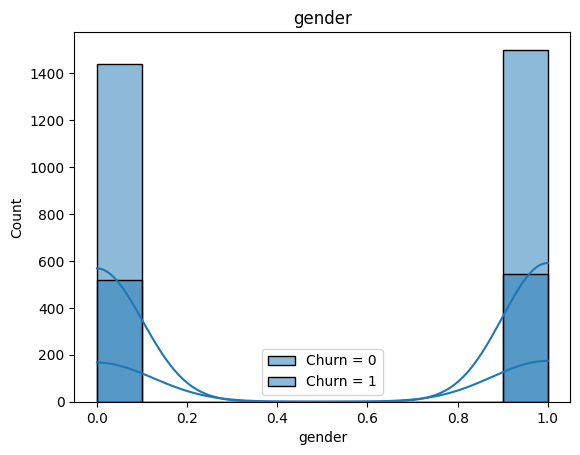

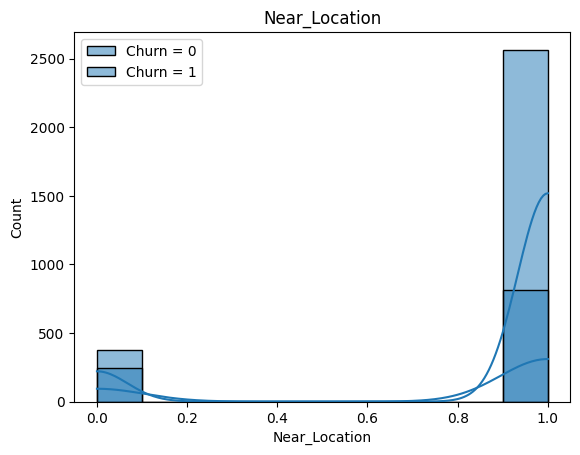

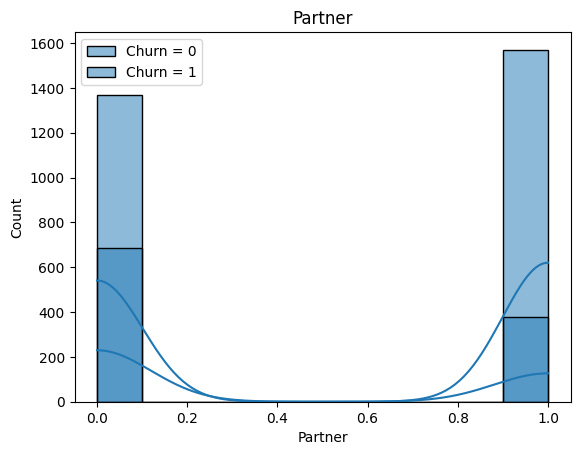

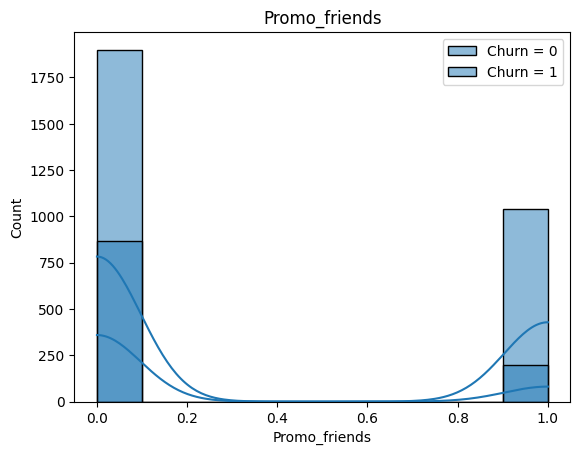

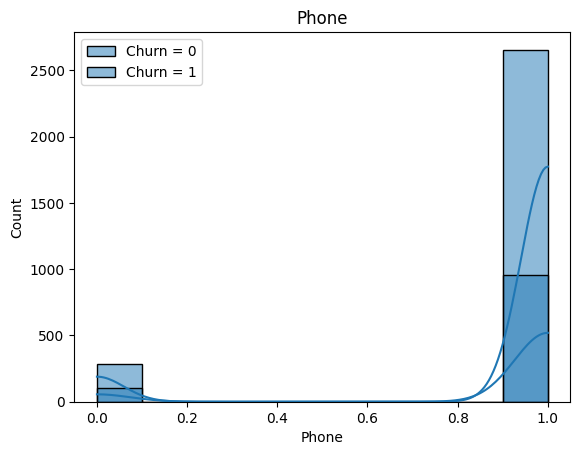

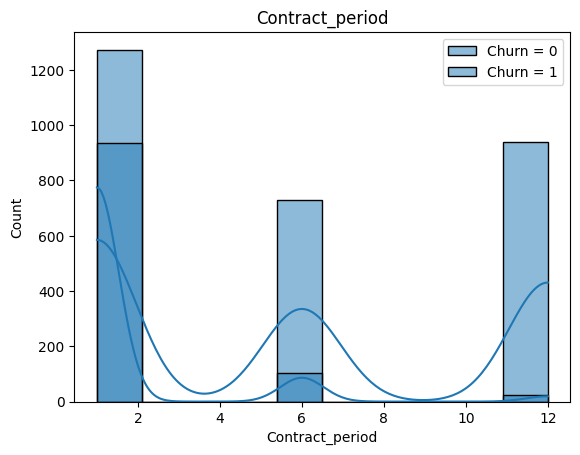

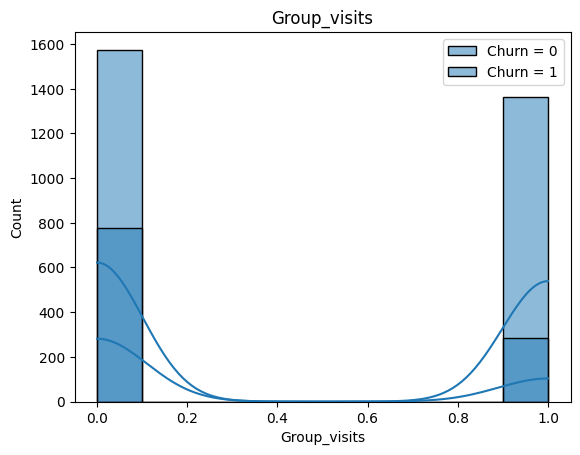

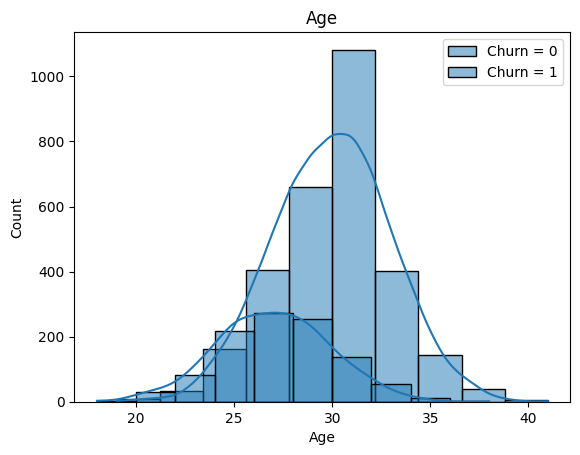

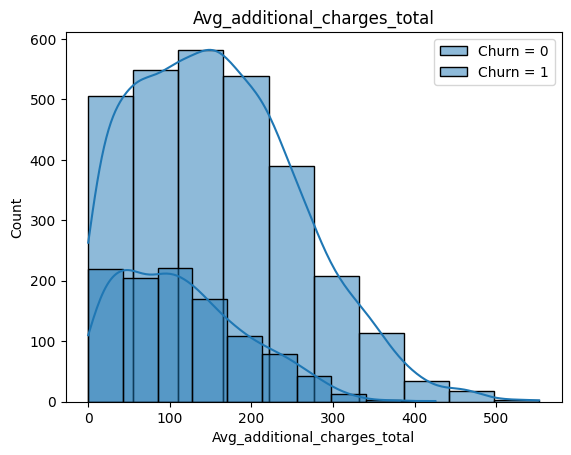

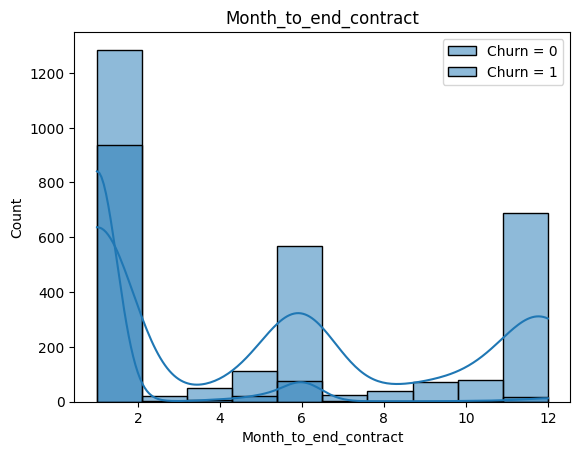

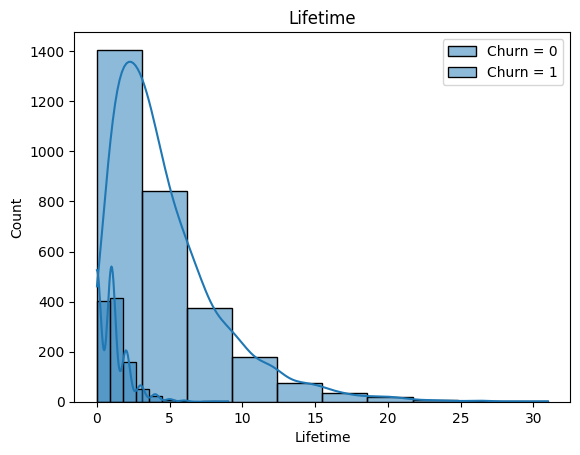

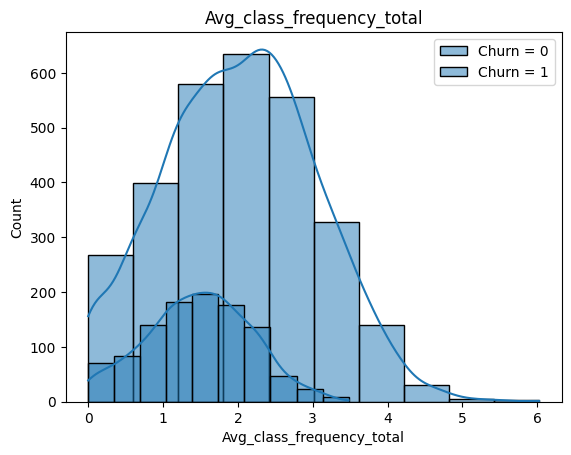

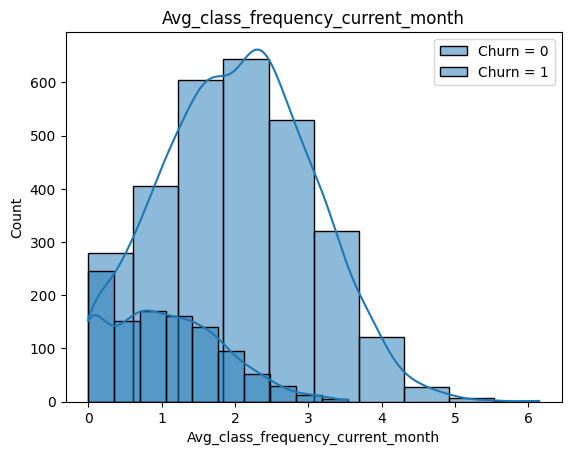

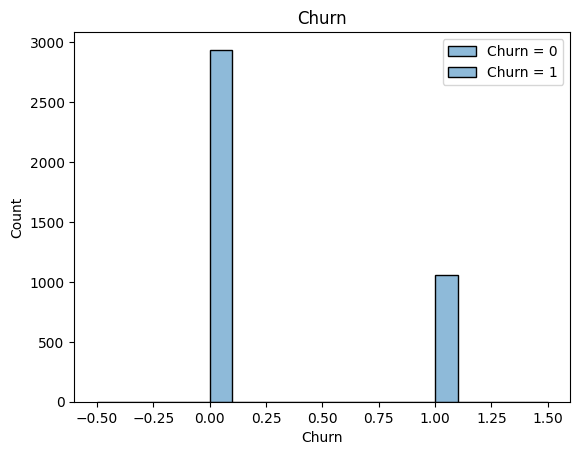

In [8]:
histograma(gym, 'Churn', gym.columns)

**Crea una matriz de correlación y muéstrala.**

In [9]:
gym.corr()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


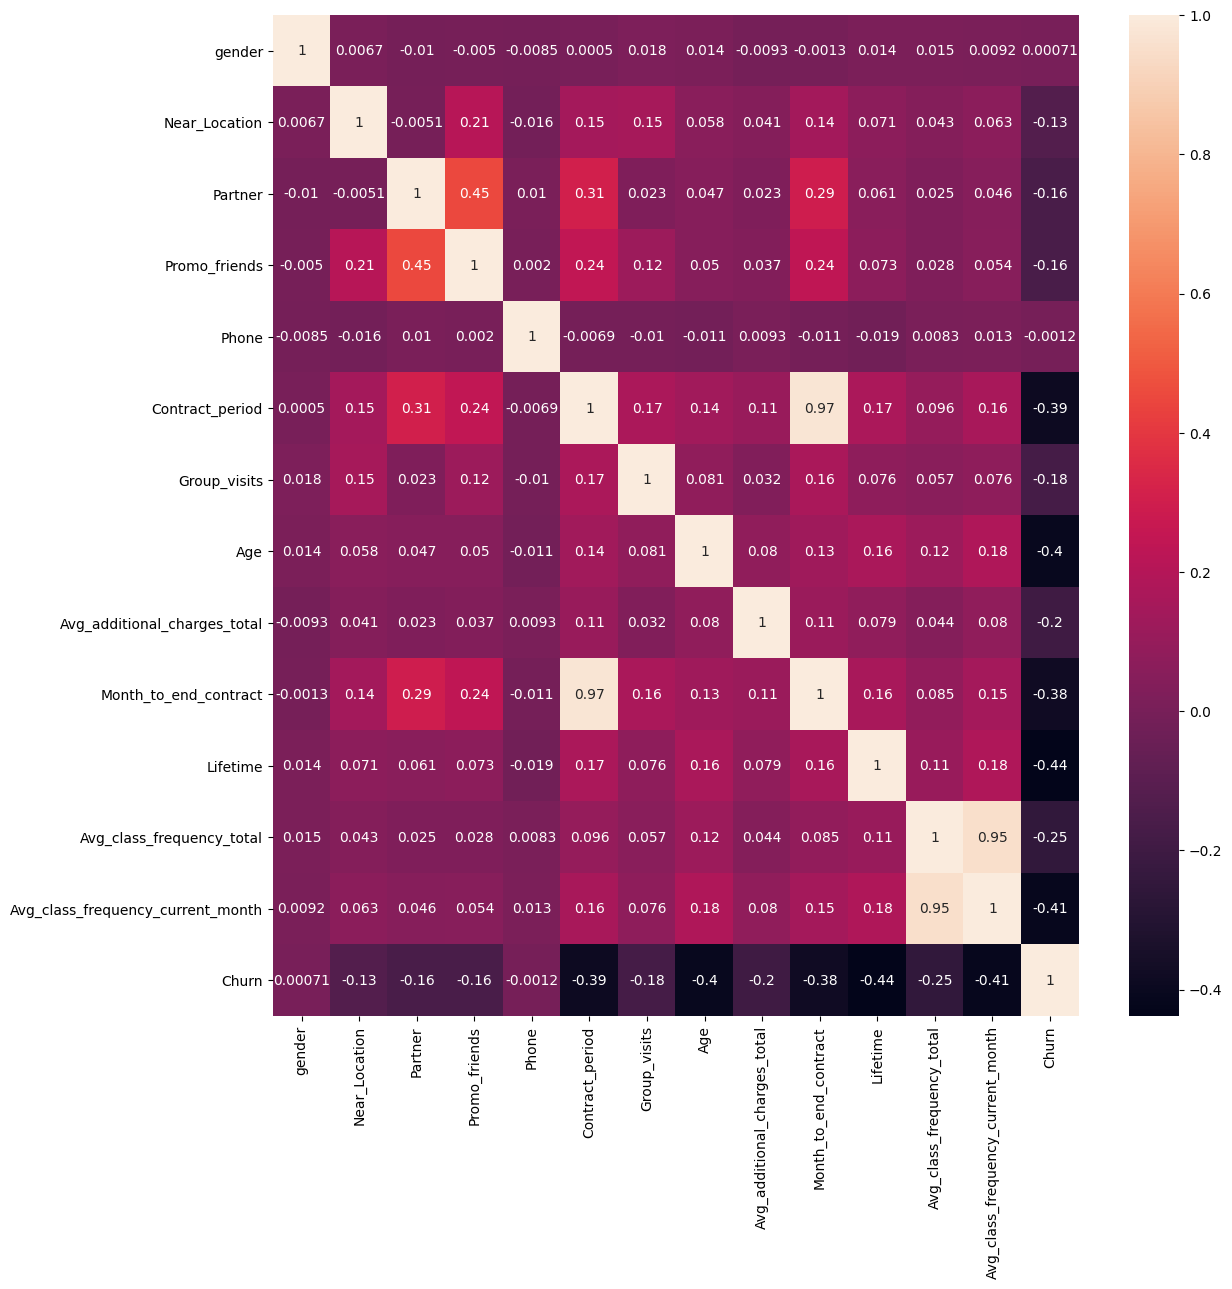

In [10]:

plt.figure(figsize=(13,13))
sns.heatmap(gym.corr(), annot=True)
plt.show();



### Paso 3.- Construir un modelo para predecir la cancelación de usuarios

Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

In [11]:

# definir características y objetivo
X = gym.drop('Churn', axis=1)
y = gym['Churn']

# dividir en entrenamiento y validación
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# modelo 1: regresión logística
model_lr = LogisticRegression(random_state=0, max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_valid)

# métricas regresión logística
acc_lr = accuracy_score(y_valid, pred_lr)
prec_lr = precision_score(y_valid, pred_lr)
rec_lr = recall_score(y_valid, pred_lr)

print('Regresión logística')
print('Accuracy:', acc_lr)
print('Precision:', prec_lr)
print('Recall:', rec_lr)




Regresión logística
Accuracy: 0.92375
Precision: 0.8586387434554974
Recall: 0.8282828282828283


In [12]:
# modelo 2: bosque aleatorio
model_rf = RandomForestClassifier(random_state=0)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_valid)

# métricas bosque aleatorio
acc_rf = accuracy_score(y_valid, pred_rf)
prec_rf = precision_score(y_valid, pred_rf)
rec_rf = recall_score(y_valid, pred_rf)

print()
print('Bosque aleatorio')
print('Accuracy:', acc_rf)
print('Precision:', prec_rf)
print('Recall:', rec_rf)


Bosque aleatorio
Accuracy: 0.91625
Precision: 0.8393782383419689
Recall: 0.8181818181818182


### Paso 4.- Crear clústeres de usuarios/as

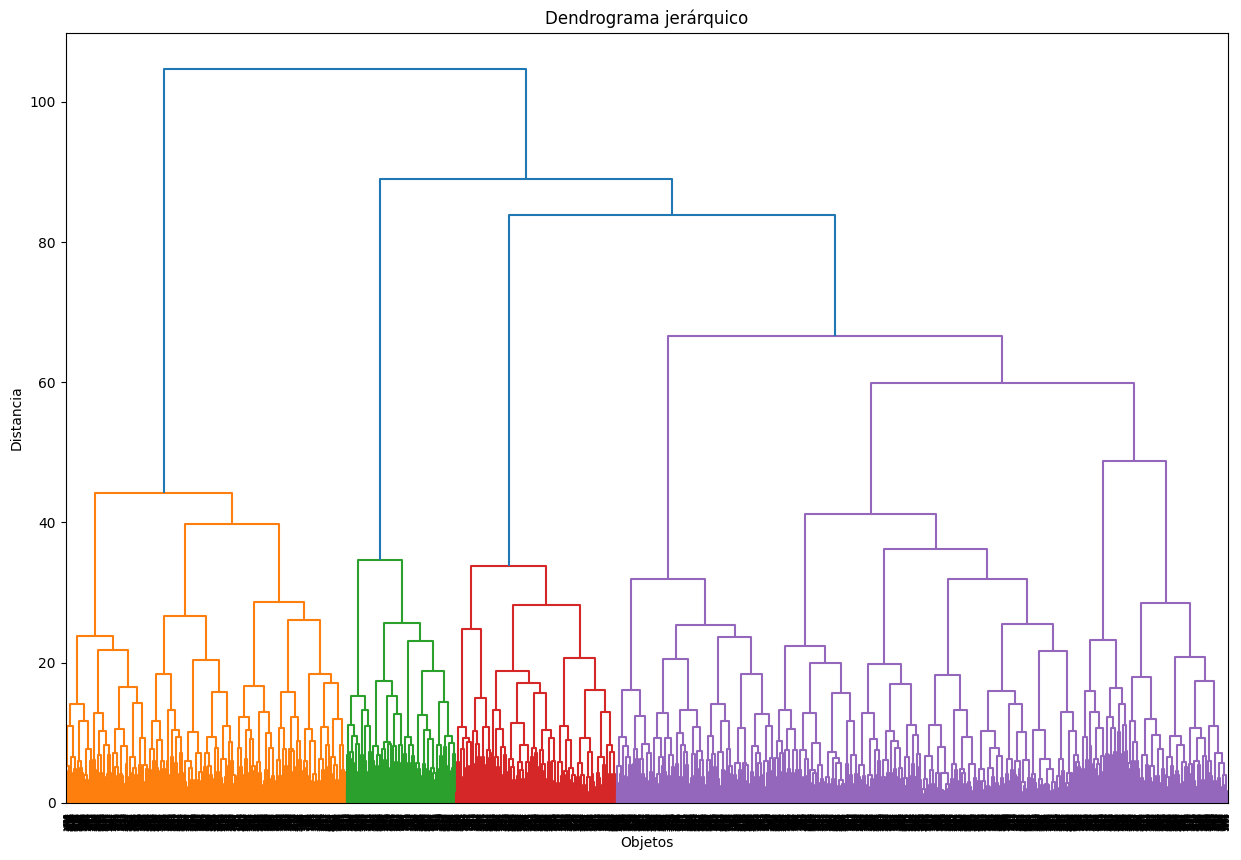

In [13]:
# Estandarizar los datos
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Crear matriz de distancias y dendrograma
linked = linkage(X_sc, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Dendrograma jerárquico')
plt.xlabel('Objetos')
plt.ylabel('Distancia')
plt.show();

In [21]:
#Entrenar K-means con n_clusters = 5
km = KMeans(n_clusters=5, random_state=0, n_init=10)
gym['cluster'] = km.fit_predict(X_sc)

# Ver valores medios por clúster
cluster_means = gym.groupby('cluster').mean(numeric_only=True)
cluster_means



,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,160.761016,9.954455,4.736634,1.982055,1.974789,0.027723
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,143.957664,4.475325,3.924675,1.847220,1.716369,0.267532
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,135.457501,2.198020,2.809901,1.660461,1.477324,0.443564
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,131.622204,1.856577,2.440571,1.247634,1.012983,0.514263
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,161.657905,2.459427,4.898568,2.852002,2.850161,0.068019


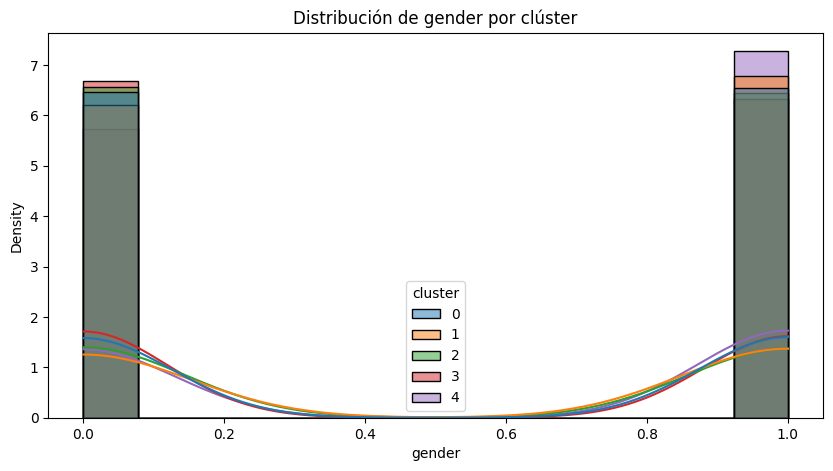

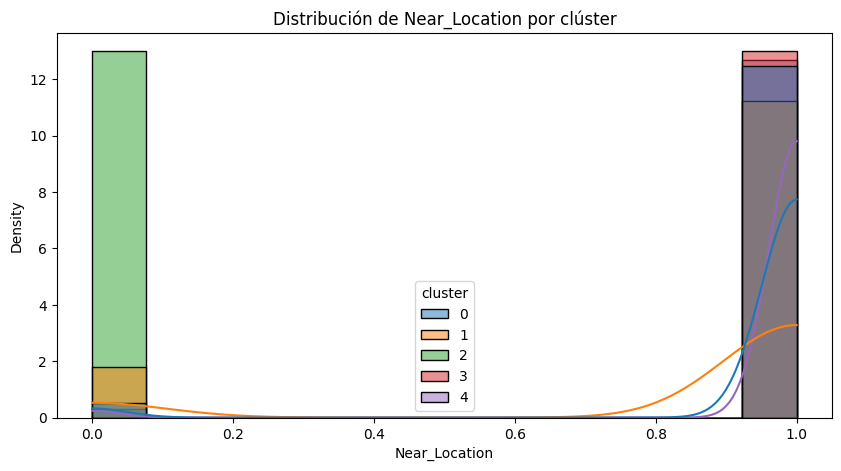

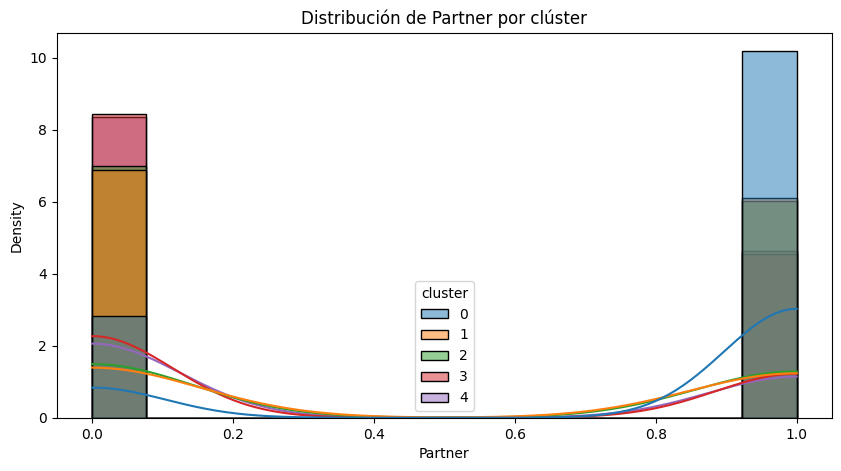

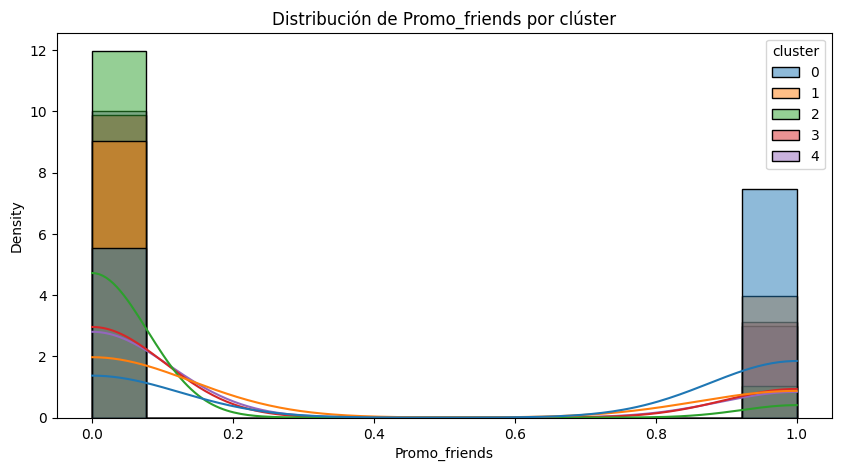

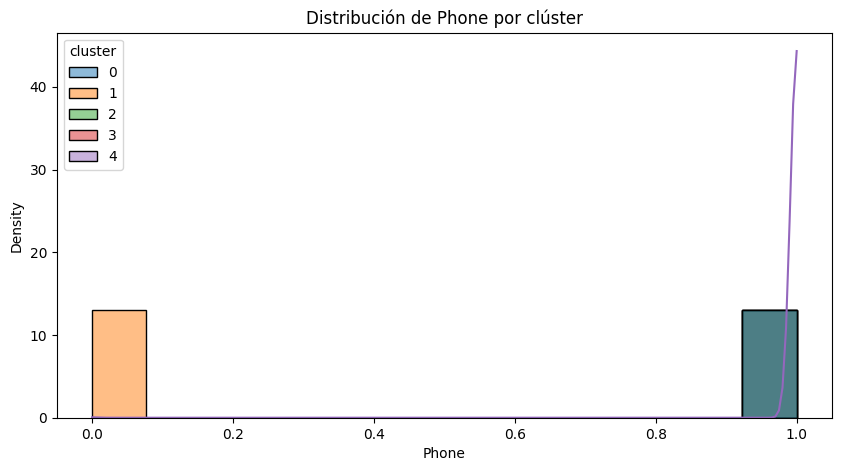

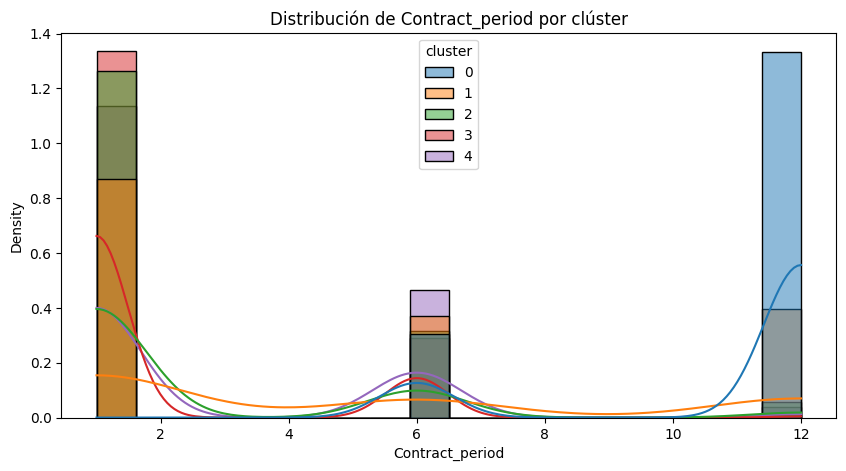

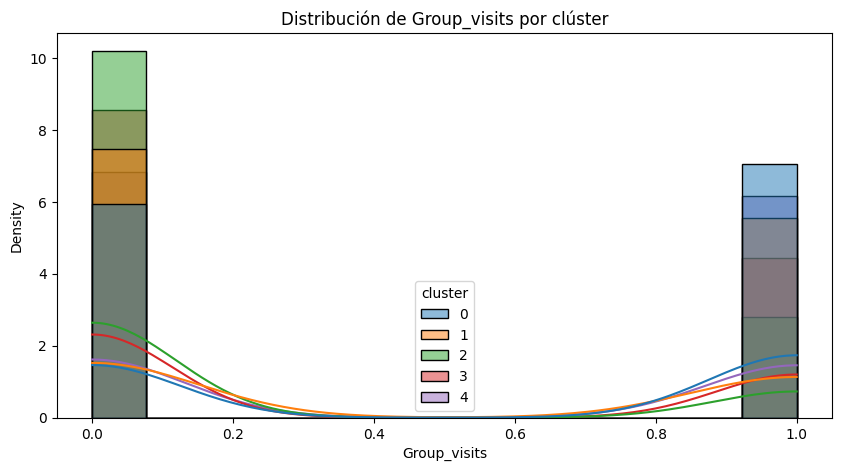

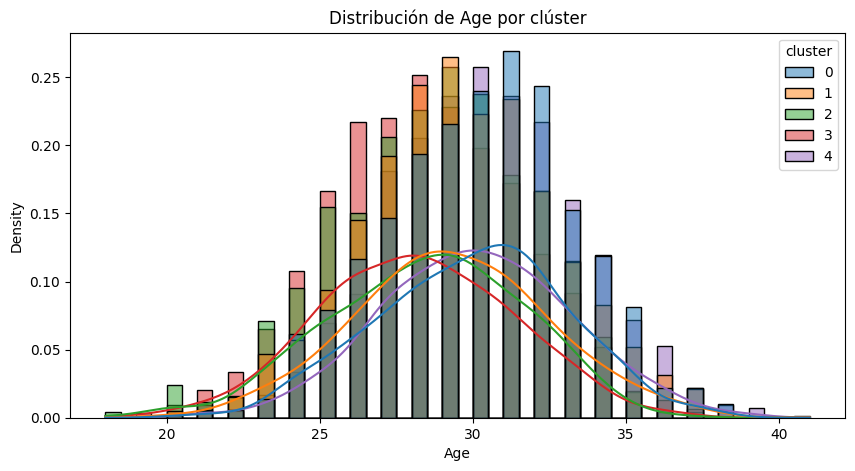

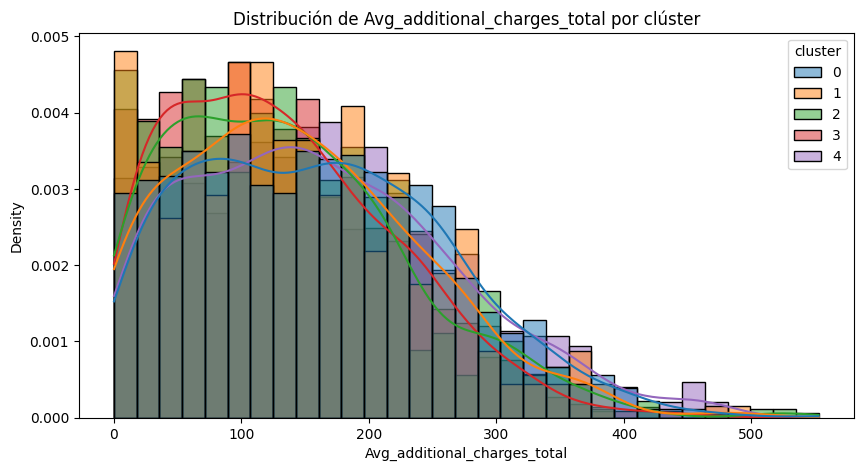

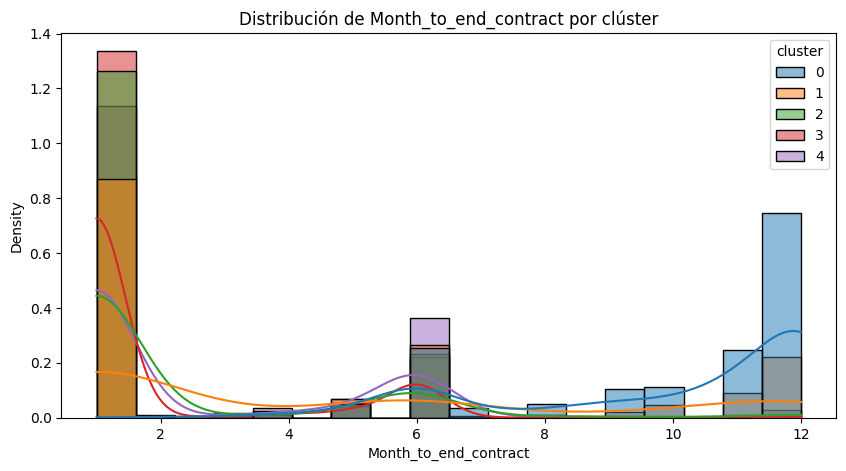

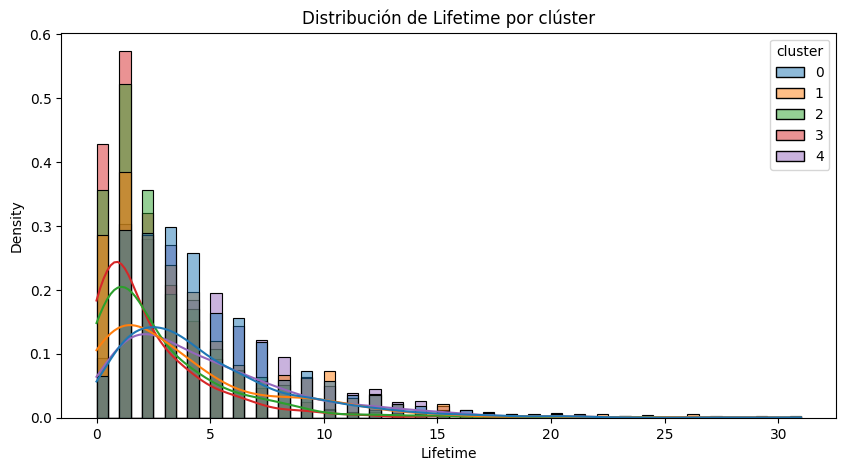

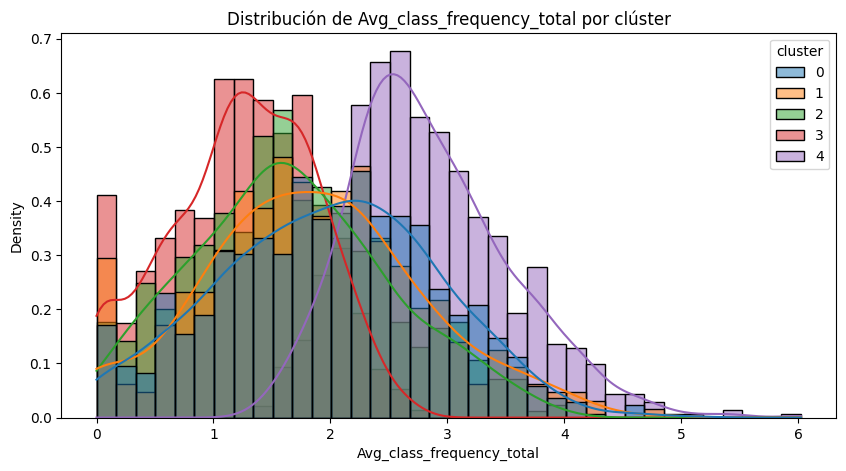

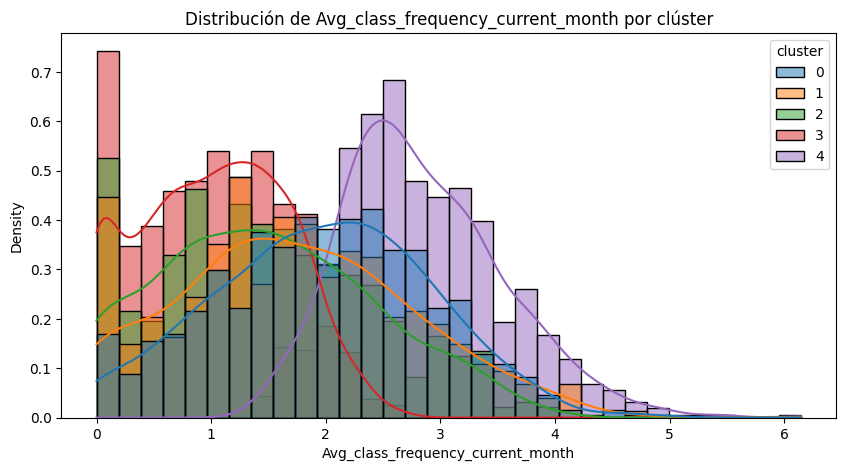

cluster
0    0.027723
1    0.267532
2    0.443564
3    0.514263
4    0.068019
Name: Churn, dtype: float64


In [20]:
# Traza distribuciones de características por clúster
for col in X.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=gym,
        x=col,
        hue='cluster',
        kde=True,
        stat='density',
        common_norm=False,
        palette='tab10'
    )
    plt.title(f'Distribución de {col} por clúster')
    plt.show()

#Tasa de cancelación por clúster
churn_by_cluster = gym.groupby('cluster')['Churn'].mean()
print(churn_by_cluster)

## Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

En general, la retención de clientes está fuertemente asociada con el nivel de compromiso (contratos largos), la frecuencia de uso y la integración del cliente en el entorno del gimnasio. Las estrategias deben enfocarse en fortalecer estos factores desde las primeras etapas del ciclo de vida del cliente.

Recomendaciones estratégicas
1. Incentivar contratos a largo plazo
Ofrecer descuentos en planes de 6 o 12 meses
Promociones como “paga 10 meses y entrena 12”
Objetivo:
Aumentar el compromiso del cliente desde el inicio

2. Aumentar la frecuencia de asistencia
Crear retos mensuales (ej: “12 visitas al mes”)
Programas de recompensas por asistencia

Objetivo:
Evitar que el cliente pierda el hábito

4. Fomentar la interacción social

Programas de referidos (“trae a un amigo”)
Clases grupales o eventos
Beneficios por entrenar en pareja
Objetivo:
Aumentar el compromiso emocional con el gimnasio